In [2]:
!pip install vnstock

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 5.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 1.1 MB/s eta 0:00:00eta 0:00:01


In [3]:
from vnstock import Quote
import pandas as pd
import time
import os

# 1. The list of the 30 individual stocks
vn30_tickers = [
    "ACB", "BCM", "BID", "BVH", "CTG", "FPT", "GAS", "GVR", "HDB", "HPG",
    "MBB", "MSN", "MWG", "PLX", "POW", "SAB", "SHB", "SSB", "SSI", "STB",
    "TCB", "TPB", "VCB", "VHM", "VIB", "VIC", "VJC", "VNM", "VPB", "VRE"
]

# Optional: Create a directory to keep your workspace clean
output_folder = "VN30_Raw_Data"
os.makedirs(output_folder, exist_ok=True)

print(f"Starting crawl for {len(vn30_tickers)} stocks...")

# 2. Loop through each ticker
for ticker in vn30_tickers:
    print(f"Fetching data for {ticker}...")
    
    try:
        # Initialize the fetcher for the specific ticker
        quote = Quote(symbol=ticker, source="KBS") 
        
        # Fetch the history
        df = quote.history(
            start="2023-01-01", 
            end="2026-02-28", 
            interval="1D"
        )
        
        # Check if the dataframe is empty (sometimes APIs fail or stocks are halted)
        if not df.empty:
            # Sort chronologically to prevent future data leaking into past data
            df = df.sort_values("time").reset_index(drop=True)
            
            # Save the file with a dynamic name (e.g., FPT_price_2023_2026.csv)
            file_path = f"{output_folder}/{ticker}_price_2023_2026.csv"
            df.to_csv(file_path, index=False)
            print(f" -> Saved {ticker} successfully. ({len(df)} rows)")
        else:
            print(f" -> Warning: No data found for {ticker}.")
            
    except Exception as e:
        print(f" -> Error fetching {ticker}: {e}")
        
    # 3. CRITICAL: Pause for 1 second between requests
    # This prevents the KBS server from thinking you are launching a DDoS attack and blocking your IP.
    time.sleep(3.5)

print("Batch crawling complete!")

Starting crawl for 30 stocks...
Fetching data for ACB...


 -> Saved ACB successfully. (783 rows)
Fetching data for BCM...
 -> Saved BCM successfully. (783 rows)
Fetching data for BID...
 -> Saved BID successfully. (783 rows)
Fetching data for BVH...
 -> Saved BVH successfully. (783 rows)
Fetching data for CTG...
 -> Saved CTG successfully. (783 rows)
Fetching data for FPT...
 -> Saved FPT successfully. (783 rows)
Fetching data for GAS...
 -> Saved GAS successfully. (783 rows)
Fetching data for GVR...
 -> Saved GVR successfully. (783 rows)
Fetching data for HDB...
 -> Saved HDB successfully. (783 rows)
Fetching data for HPG...
 -> Saved HPG successfully. (783 rows)
Fetching data for MBB...
 -> Saved MBB successfully. (783 rows)
Fetching data for MSN...
 -> Saved MSN successfully. (783 rows)
Fetching data for MWG...
 -> Saved MWG successfully. (783 rows)
Fetching data for PLX...
 -> Saved PLX successfully. (783 rows)
Fetching data for POW...
 -> Saved POW successfully. (783 rows)
Fetching data for SAB...
 -> Saved SAB successfully. (783 rows)
F

In [6]:
!zip -r VN30_Raw_Data.zip D:\Projects\AI itec2 FTU\VN30STOCK

	zip warning: name not matched: D:ProjectsAI
	zip warning: name not matched: itec2
	zip warning: name not matched: FTUVN30STOCK

zip error: Nothing to do! (try: zip -r VN30_Raw_Data.zip . -i D:ProjectsAI itec2 FTUVN30STOCK)


In [6]:
!pip install pandas_ta

In [8]:
#Code feature engineering
import pandas as pd
import pandas_ta as ta

def apply_smart_indicators(df):
    """
    Tính toán và biến đổi các chỉ báo thành dạng 'Khoảng cách' hoặc 'Tỷ lệ %'
    để tránh Overkill và Đa cộng tuyến cho mô hình AI.
    """
    # XỬ LÝ LỖI GIÁ QUÁ NHỎ: Nhân OHLC với 1000 nếu dữ liệu gốc bị thu nhỏ
    # (Fix lỗi decimal của một số API chứng khoán VN)
    if df['close'].mean() < 500: 
        df[['open', 'high', 'low', 'close']] = df[['open', 'high', 'low', 'close']] * 1000

    # 1. Khối lượng (Tính tỷ lệ thay đổi % thay vì giá trị tuyệt đối)
    df['Volume_pct'] = df['volume'].pct_change()

    # 2. RSI (Mặc định 14 - Scale chuẩn 0-100 rất tốt cho AI)
    df['RSI_14'] = df.ta.rsi(length=14)

    # 3. MACD (Chỉ lấy cột Histogram để xem xung lượng mua/bán)
    macd = df.ta.macd(fast=12, slow=26, signal=9)
    if macd is not None:
        df['MACD_Hist'] = macd.iloc[:, 1]

    # 4. Bollinger Bands (Dùng %B: Vị trí tương đối của giá trong dải băng)
    # %B = 1 (Giá chạm band trên), %B = 0 (Giá chạm band dưới)
    bb = df.ta.bbands(length=14, std=2)
    if bb is not None:
        df['BB_pctB'] = bb.iloc[:, 3] 

    # 5. Ichimoku Kijun 65 (Tính khoảng cách % từ giá đến đường cơ sở)
    ichi, _ = df.ta.ichimoku(tenkan=1, kijun=65, senkou=1)
    if ichi is not None:
        kijun_col = [c for c in ichi.columns if 'IKS' in c][0] # Tìm cột Kijun Sen
        df['Kijun_65_Dist'] = (df['close'] - ichi[kijun_col]) / ichi[kijun_col]

    # 6. Moving Averages (Tính khoảng cách % thay vì giá tuyệt đối)
    ema9 = df['close'].ewm(span=9, adjust=False).mean()
    ma50 = df['close'].rolling(window=50).mean()
    
    df['EMA9_Dist'] = (df['close'] - ema9) / ema9
    df['MA50_Dist'] = (df['close'] - ma50) / ma50

    return df

In [9]:
#Code train
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import os
import pandas_ta as ta # Đảm bảo import thư viện

# --- 1. Global Parameters ---
SEQ_LENGTH = 30
# Sử dụng các features đã được tối ưu hóa để tránh đa cộng tuyến
FEATURES = ['close', 'Volume_pct', 'RSI_14', 'MACD_Hist', 'BB_pctB', 'Kijun_65_Dist', 'EMA9_Dist', 'MA50_Dist']

VN30_TICKERS = [
    "ACB", "BCM", "BID", "BVH", "CTG", "FPT", "GAS", "GVR", "HDB", "HPG",
    "MBB", "MSN", "MWG", "PLX", "POW", "SAB", "SHB", "SSB", "SSI", "STB",
    "TCB", "TPB", "VCB", "VHM", "VIB", "VIC", "VJC", "VNM", "VPB", "VRE"
]

DATA_DIR = "/kaggle/working/VN30_Raw_Data"
PLOT_DIR = "/kaggle/working/VN30_Trend_Plots"

global_X_train, global_y_train = [], []
stock_test_data = {}

# --- 2. Data Processing ---
print(f"Looking for data inside: {DATA_DIR}")
print("Processing data, applying Smart Indicators, and calculating Targets...")

for ticker in VN30_TICKERS:
    file_name = os.path.join(DATA_DIR, f"{ticker}_price_2023_2026.csv")
    if not os.path.exists(file_name):
        continue
        
    df = pd.read_csv(file_name)
    df['time'] = pd.to_datetime(df['time'])
    
    # GỌI HÀM TẠO CHỈ BÁO ĐÃ ĐỊNH NGHĨA Ở CELL TRƯỚC
    df = apply_smart_indicators(df)
    
    # Calculate 3-Day Future Average Price (Target)
    df['Future_3D_Avg'] = df['close'].rolling(window=3).mean().shift(-3)
    df['Target_Return'] = (df['Future_3D_Avg'] - df['close']) / df['close']
    
    # Dropna rất quan trọng vì các chỉ báo như MA50, Ichimoku 65 sẽ tạo ra ~65 dòng NaN đầu tiên
    df_clean = df.dropna().reset_index(drop=True)
    
    if df_clean.empty or len(df_clean) < SEQ_LENGTH * 2:
        print(f"Not enough data for {ticker} after applying indicators. Skipping.")
        continue
    
    # Scale inputs between 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_features = scaler.fit_transform(df_clean[FEATURES].values)
    
    # Extract raw target arrays
    target_returns = df_clean['Target_Return'].values
    current_close_prices = df_clean['close'].values
    future_avg_prices = df_clean['Future_3D_Avg'].values
    
    # Create Sequences
    xs, ys, last_prices, actual_future_targets = [], [], [], []
    for i in range(len(scaled_features) - SEQ_LENGTH):
        t = i + SEQ_LENGTH - 1
        xs.append(scaled_features[i:(t + 1)])
        ys.append(target_returns[t]) 
        last_prices.append(current_close_prices[t])
        actual_future_targets.append(future_avg_prices[t])
        
    X = np.array(xs)
    y = np.array(ys)
    last_prices = np.array(last_prices)
    actual_future_targets = np.array(actual_future_targets)
    
    # Split Train (80%) and Test (20%)
    split_idx = int(len(X) * 0.8)
    
    global_X_train.extend(X[:split_idx])
    global_y_train.extend(y[:split_idx])
    
    stock_test_data[ticker] = {
        'X_test': torch.tensor(X[split_idx:], dtype=torch.float32),
        'last_actual_prices': last_prices[split_idx:], 
        'actual_future_targets': actual_future_targets[split_idx:] 
    }

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(np.array(global_X_train), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(global_y_train), dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
print(f"Global Master Dataset created! Total training sequences: {len(X_train_tensor)}")

# --- 3. The Global Model ---
class GlobalTrendPredictor(nn.Module):
    # CHỈNH SỬA: input_size giờ sẽ tự động nhận diện số lượng FEATURES
    def __init__(self, input_size=len(FEATURES), hidden_size=64, num_layers=2):
        super(GlobalTrendPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:, -1, :])

model = GlobalTrendPredictor()
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- 4. Training Loop ---
epochs = 50 
print("Training the Global AI Model on 3-Day Trends...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Global Loss (MSE of Returns): {total_loss/len(train_loader):.6f}")

# --- 5. Generate Plots by Reconstructing Prices ---
print(f"Generating separate prediction plots inside {PLOT_DIR}...")
os.makedirs(PLOT_DIR, exist_ok=True)
model.eval()

with torch.no_grad():
    for ticker, data in stock_test_data.items():
        X_test = data['X_test']
        predicted_returns = model(X_test).numpy().flatten()
        
        # Predicted Future 3D Avg = Last Known Price * (1 + Predicted Return)
        last_known_prices = data['last_actual_prices']
        predicted_future_avg = last_known_prices * (1 + predicted_returns)
        actual_future_avg = data['actual_future_targets']
        
        plt.figure(figsize=(12, 6))
        plt.plot(actual_future_avg, label='Actual 3-Day Avg Price', color='blue')
        plt.plot(predicted_future_avg, label='Predicted 3-Day Avg Price', color='red', linestyle='--')
        
        plt.title(f'{ticker}: Actual vs Predicted 3-Day Trend')
        plt.xlabel('Days in Test Set')
        plt.ylabel('Price (VND)')
        plt.legend()
        plt.grid(True)
        
        plt.savefig(os.path.join(PLOT_DIR, f"{ticker}_trend_prediction.png"))
        plt.close()

print(f"Done! Check the '{PLOT_DIR}' folder.")

Looking for data inside: /kaggle/working/VN30_Raw_Data
Processing data, applying Smart Indicators, and calculating Targets...
Global Master Dataset created! Total training sequences: 13440
Training the Global AI Model on 3-Day Trends...
Epoch 10/50 | Global Loss (MSE of Returns): 0.000472
Epoch 20/50 | Global Loss (MSE of Returns): 0.000459
Epoch 30/50 | Global Loss (MSE of Returns): 0.000453
Epoch 40/50 | Global Loss (MSE of Returns): 0.000437
Epoch 50/50 | Global Loss (MSE of Returns): 0.000422
Generating separate prediction plots inside /kaggle/working/VN30_Trend_Plots...
Done! Check the '/kaggle/working/VN30_Trend_Plots' folder.


In [10]:
from sklearn.metrics import mean_squared_error
import pandas as pd

model.eval()
mse_results = {}

print("--------------------------------------------------")
print("TEST MSE FOR INDIVIDUAL STOCKS")
print("--------------------------------------------------")

with torch.no_grad():
    for ticker, data in stock_test_data.items():
        # 1. Predict on the GPU, pull back to CPU
        X_test = data['X_test']
        predicted_returns = model(X_test).cpu().numpy().flatten()
        
        # 2. Calculate the actual returns
        last_known_prices = data['last_actual_prices']
        actual_future_avg = data['actual_future_targets']
        actual_returns = (actual_future_avg - last_known_prices) / last_known_prices
        
        # 3. Calculate MSE for this specific stock
        stock_mse = mean_squared_error(actual_returns, predicted_returns)
        mse_results[ticker] = stock_mse
        
        # Print individual results
        print(f"{ticker}: {stock_mse:.6f}")

# --- Data Science Bonus: Sort and Analyze ---
# Convert to a Pandas DataFrame to easily sort and find the best/worst
mse_df = pd.DataFrame(list(mse_results.items()), columns=['Ticker', 'Test_MSE'])
mse_df = mse_df.sort_values(by='Test_MSE').reset_index(drop=True)

print("\n🏆 Top 5 BEST Predicted Stocks (Lowest Error):")
print(mse_df.head().to_string(index=False))

print("\n⚠️ Top 5 HARDEST to Predict Stocks (Highest Error):")
print(mse_df.tail().to_string(index=False))

# Calculate the Overall Average MSE just to have it
overall_avg = mse_df['Test_MSE'].mean()
print(f"\n=> Overall Average MSE across all 30 stocks: {overall_avg:.6f}")

--------------------------------------------------
TEST MSE FOR INDIVIDUAL STOCKS
--------------------------------------------------
ACB: 0.000504
BCM: 0.000352
BID: 0.000405
BVH: 0.000835
CTG: 0.000528
FPT: 0.000569
GAS: 0.000342
GVR: 0.000688
HDB: 0.000988
HPG: 0.000611
MBB: 0.001048
MSN: 0.000797
MWG: 0.000633
PLX: 0.000378
POW: 0.000547
SAB: 0.000133
SHB: 0.001311
SSB: 0.000583
SSI: 0.001149
STB: 0.000801
TCB: 0.000802
TPB: 0.001025
VCB: 0.000325
VHM: 0.001642
VIB: 0.000701
VIC: 0.002225
VJC: 0.002113
VNM: 0.000410
VPB: 0.001559
VRE: 0.001477

🏆 Top 5 BEST Predicted Stocks (Lowest Error):
Ticker  Test_MSE
   SAB  0.000133
   VCB  0.000325
   GAS  0.000342
   BCM  0.000352
   PLX  0.000378

⚠️ Top 5 HARDEST to Predict Stocks (Highest Error):
Ticker  Test_MSE
   VRE  0.001477
   VPB  0.001559
   VHM  0.001642
   VJC  0.002113
   VIC  0.002225

=> Overall Average MSE across all 30 stocks: 0.000849


Found 30 plots. Displaying them now...



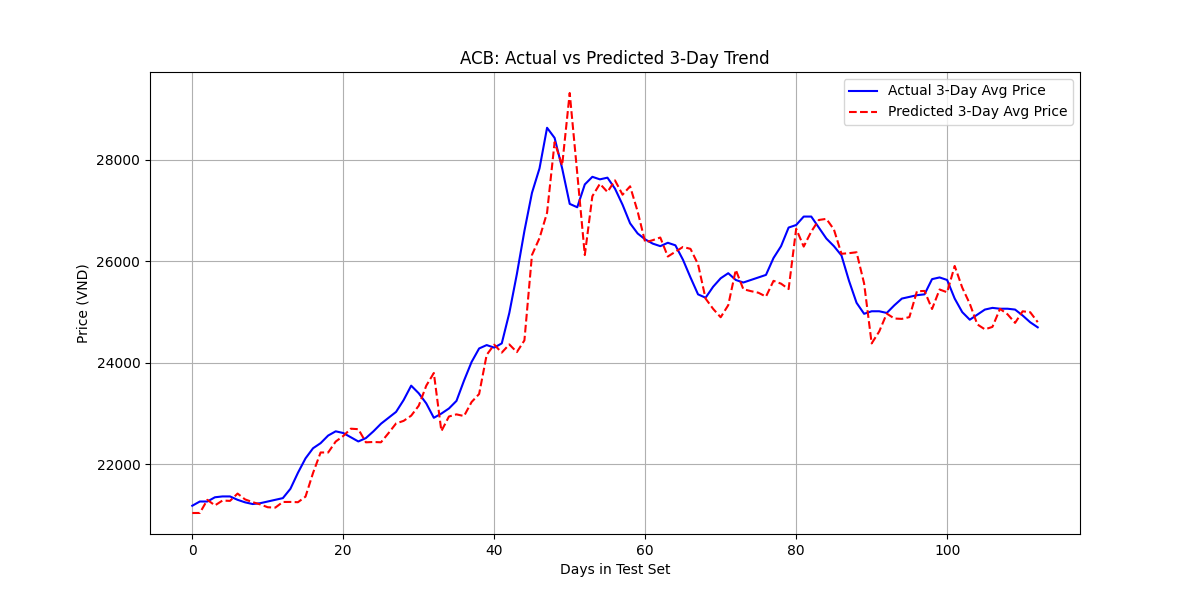

--------------------------------------------------------------------------------


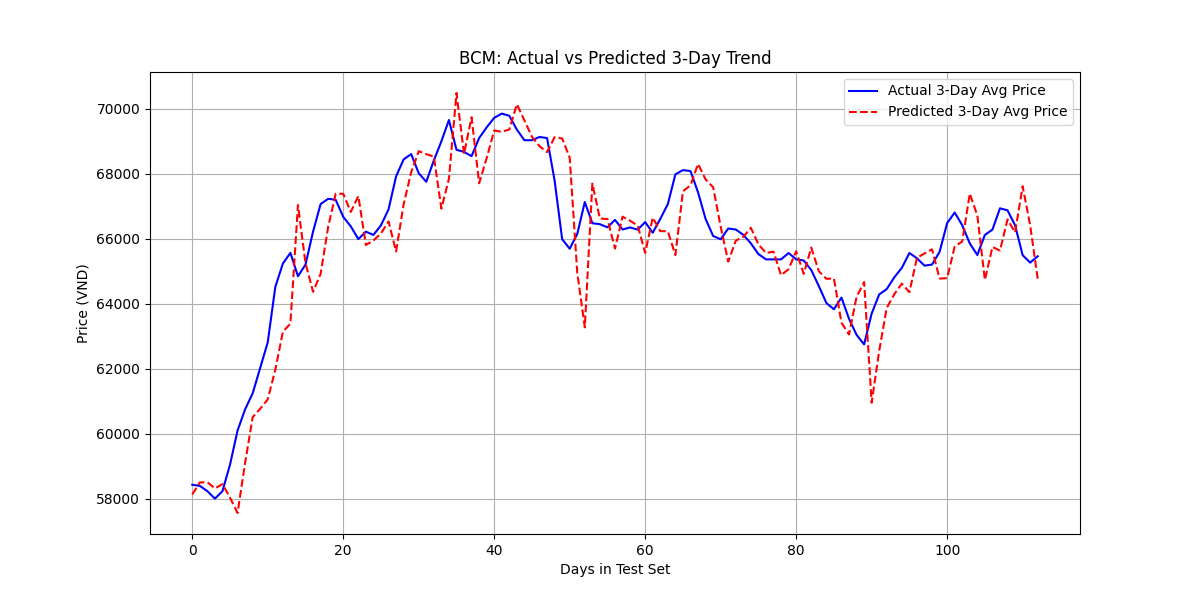

--------------------------------------------------------------------------------


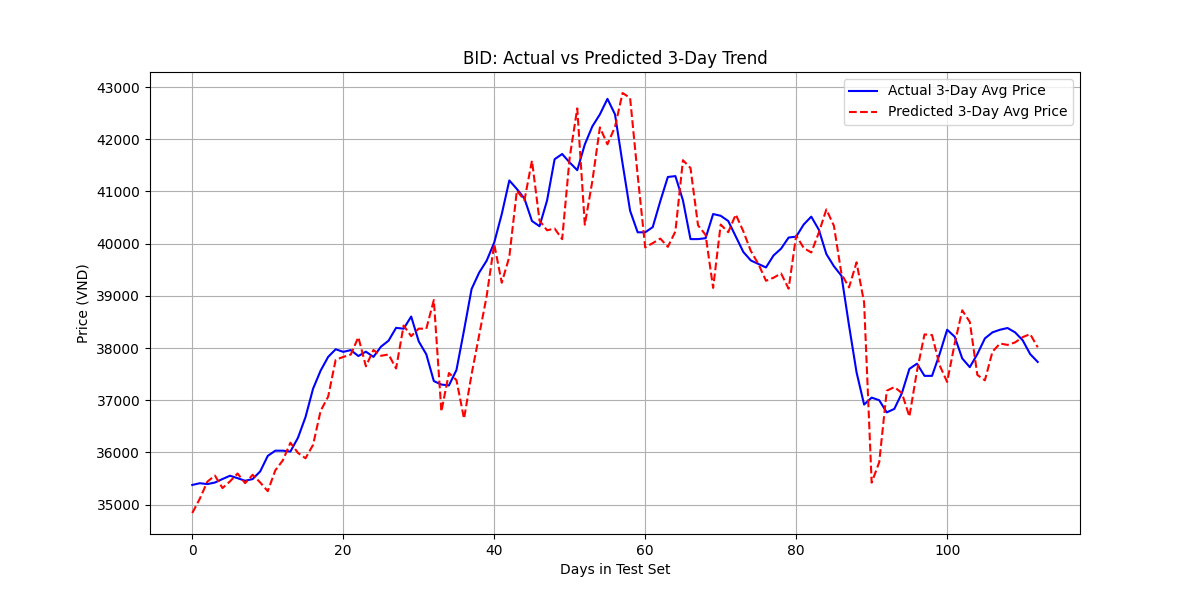

--------------------------------------------------------------------------------


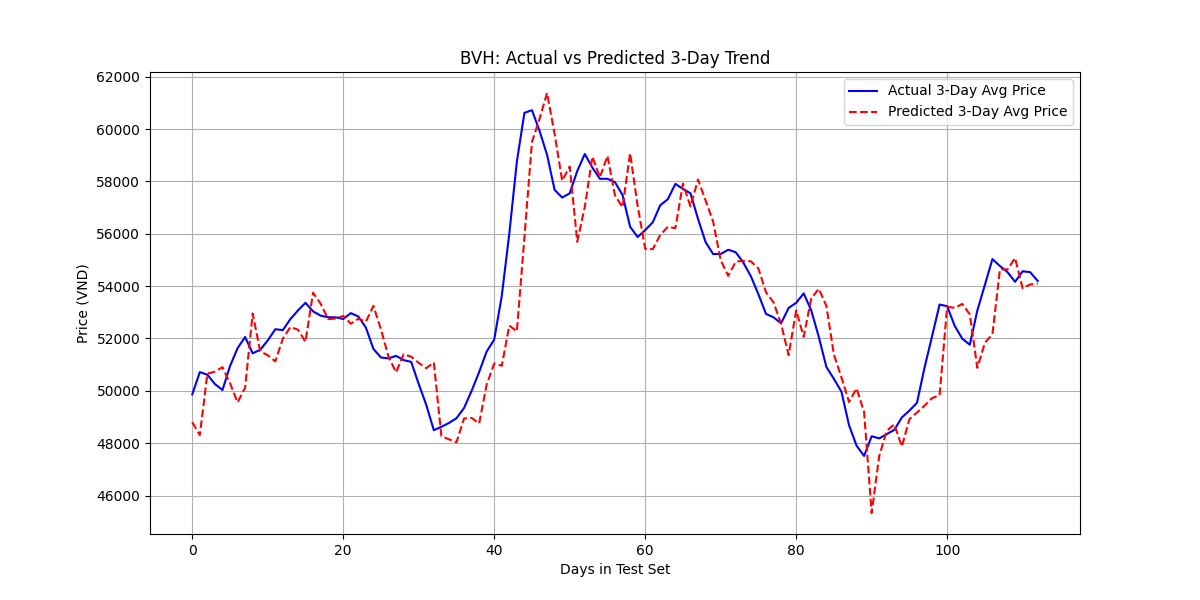

--------------------------------------------------------------------------------


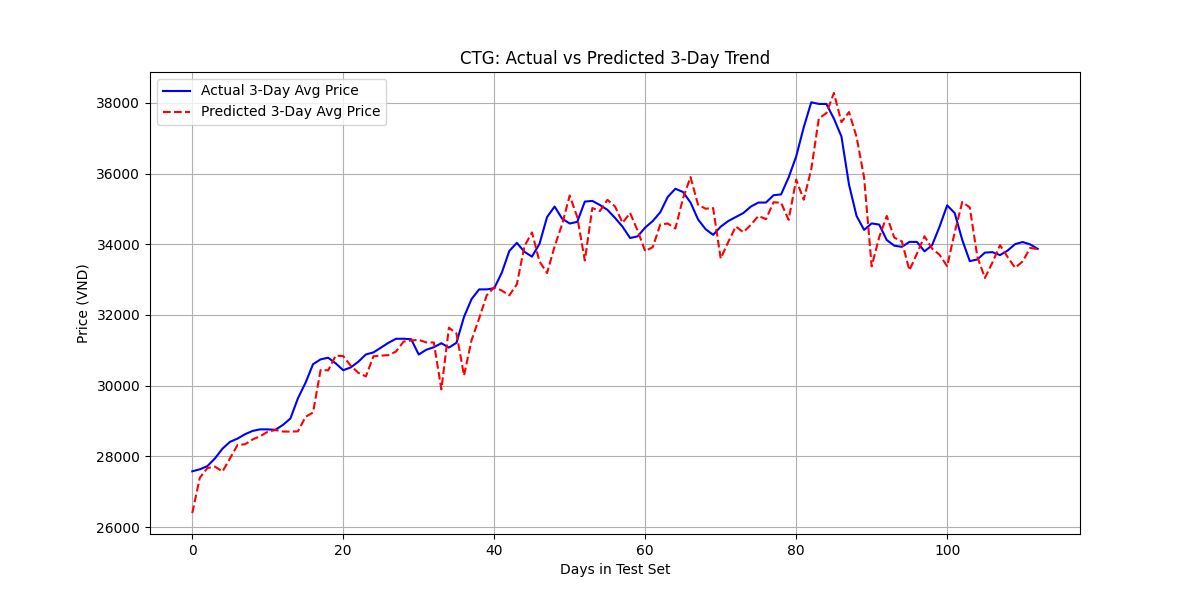

--------------------------------------------------------------------------------


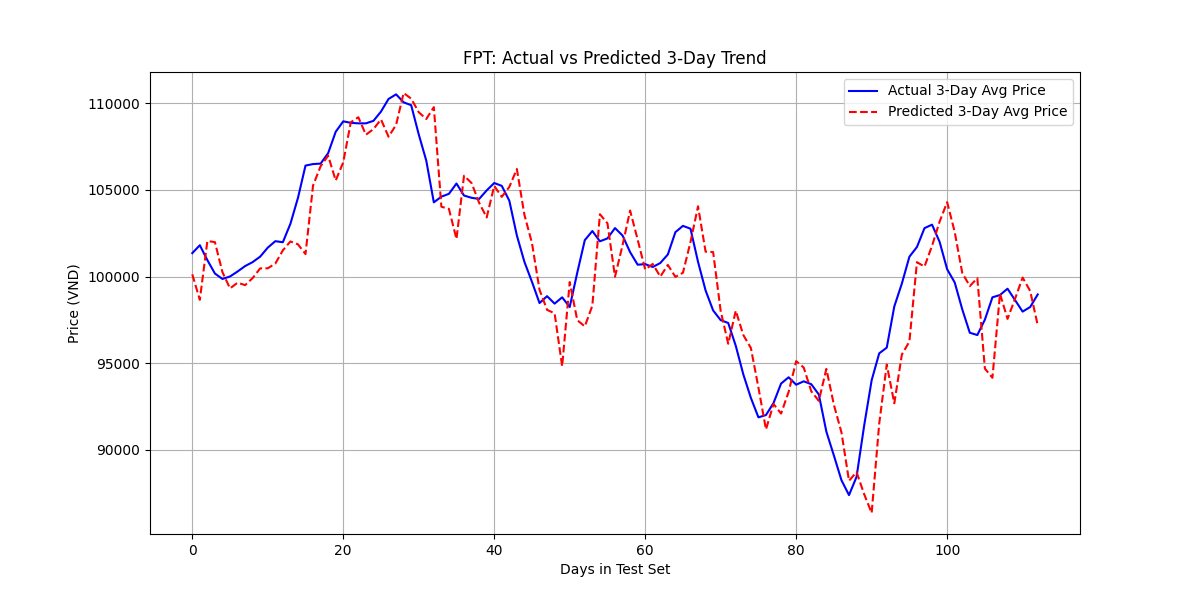

--------------------------------------------------------------------------------


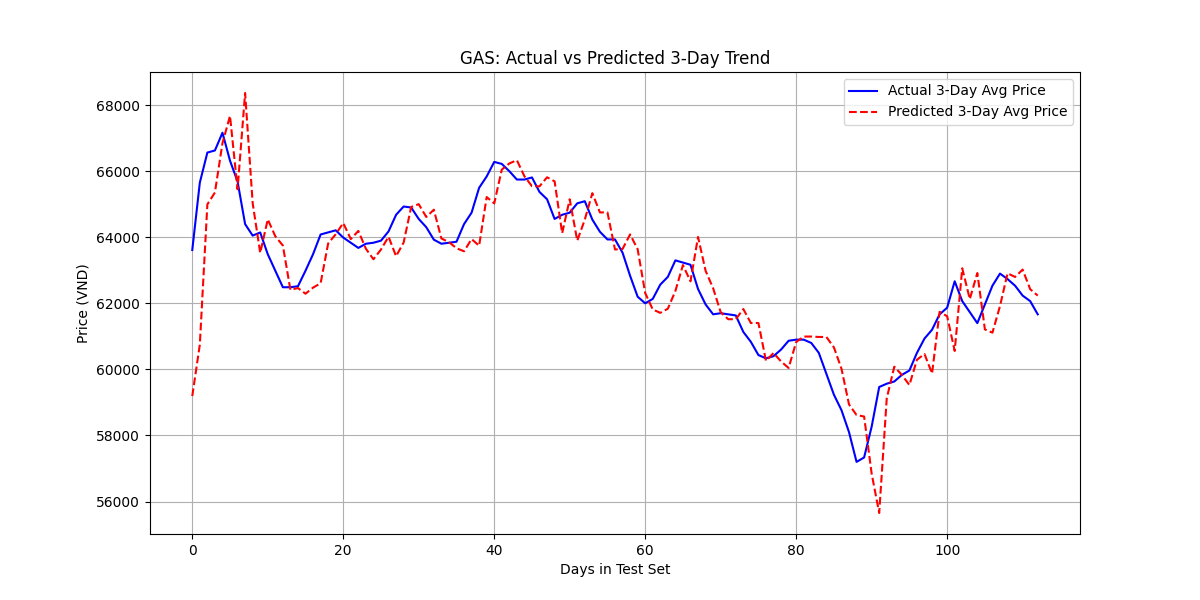

--------------------------------------------------------------------------------


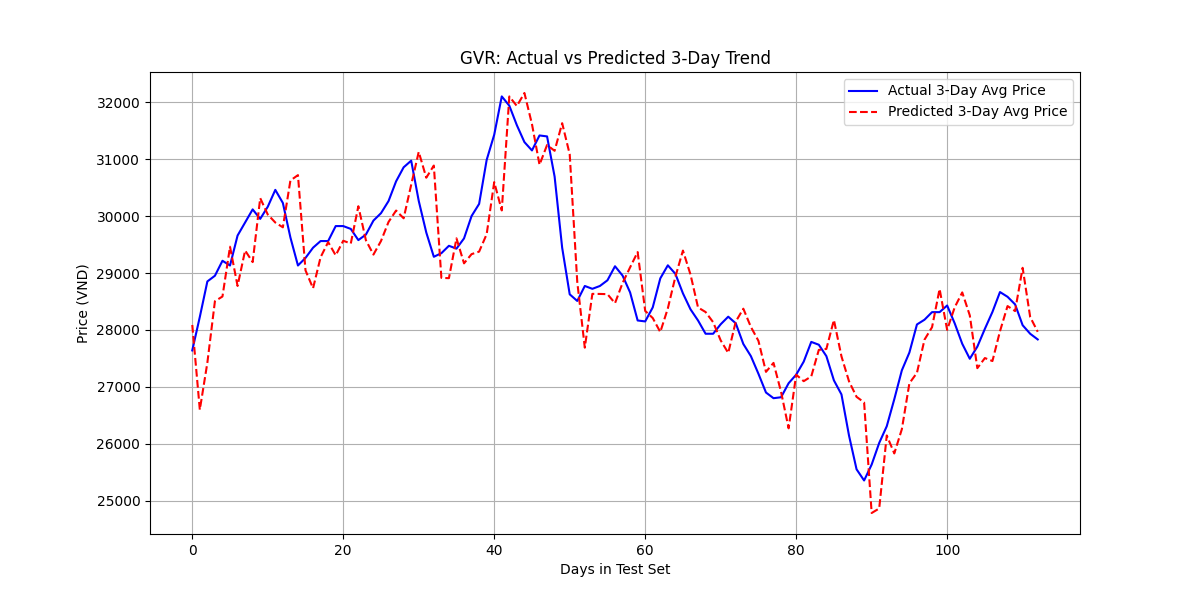

--------------------------------------------------------------------------------


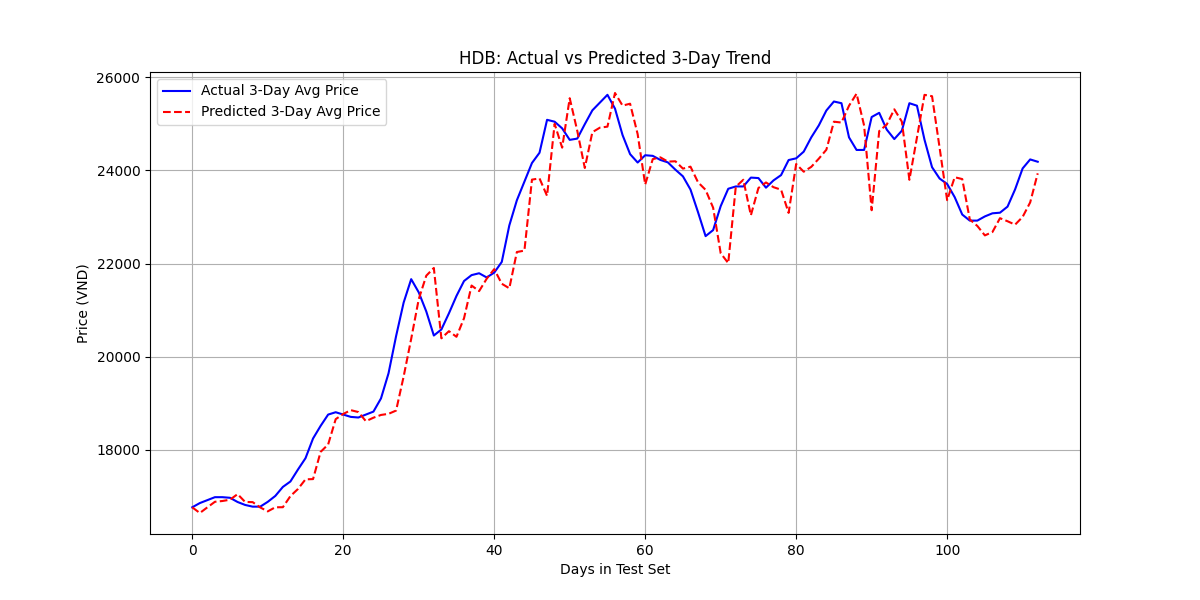

--------------------------------------------------------------------------------


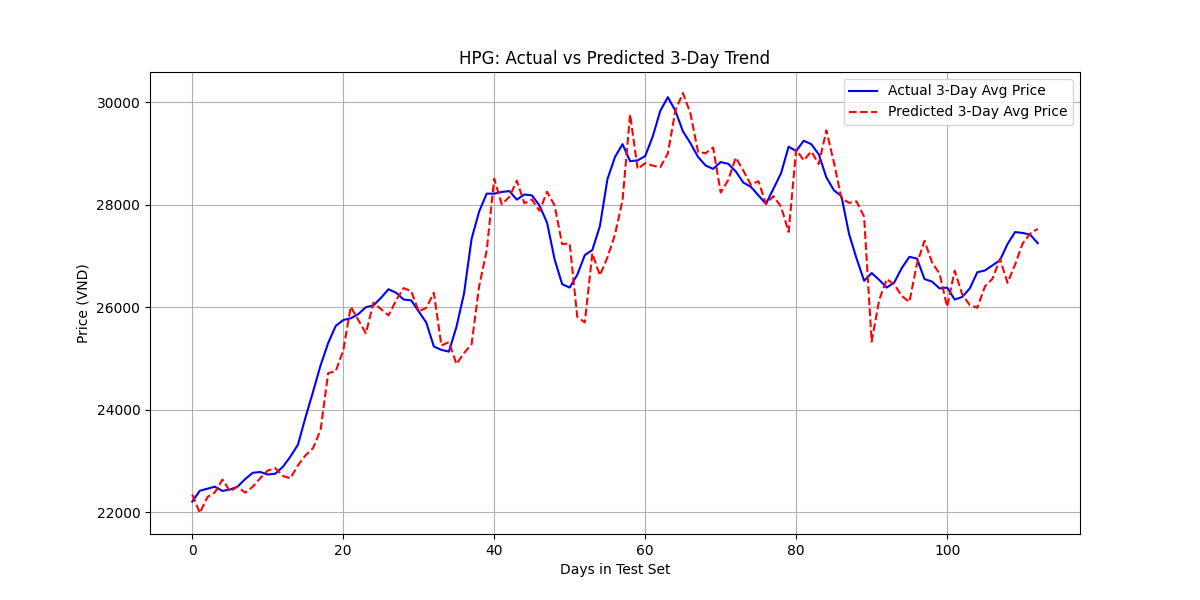

--------------------------------------------------------------------------------


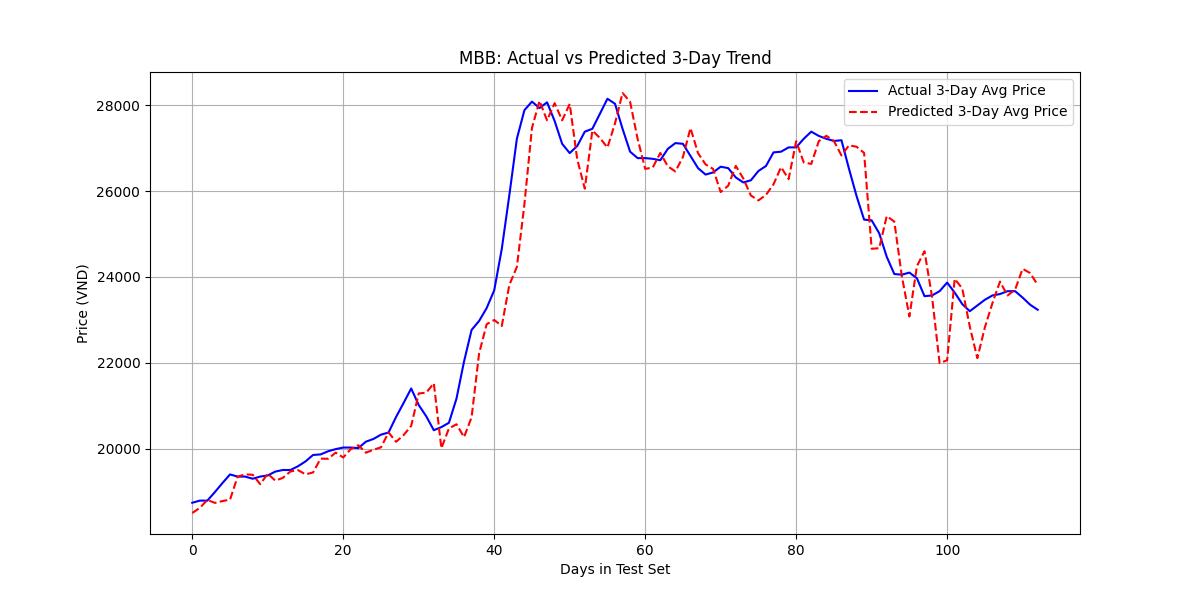

--------------------------------------------------------------------------------


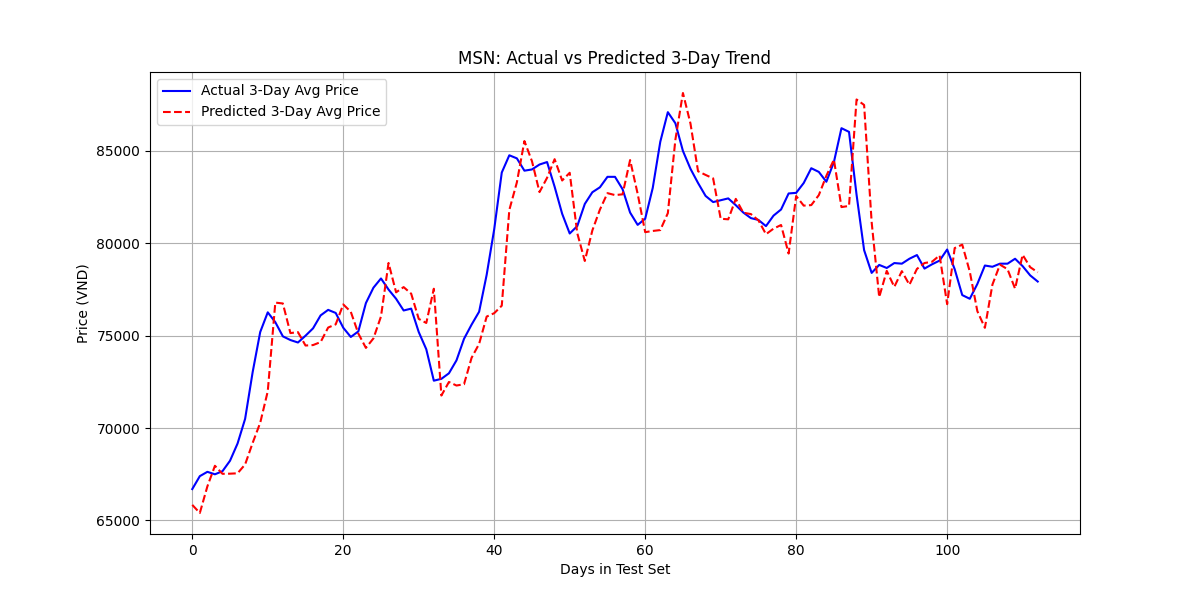

--------------------------------------------------------------------------------


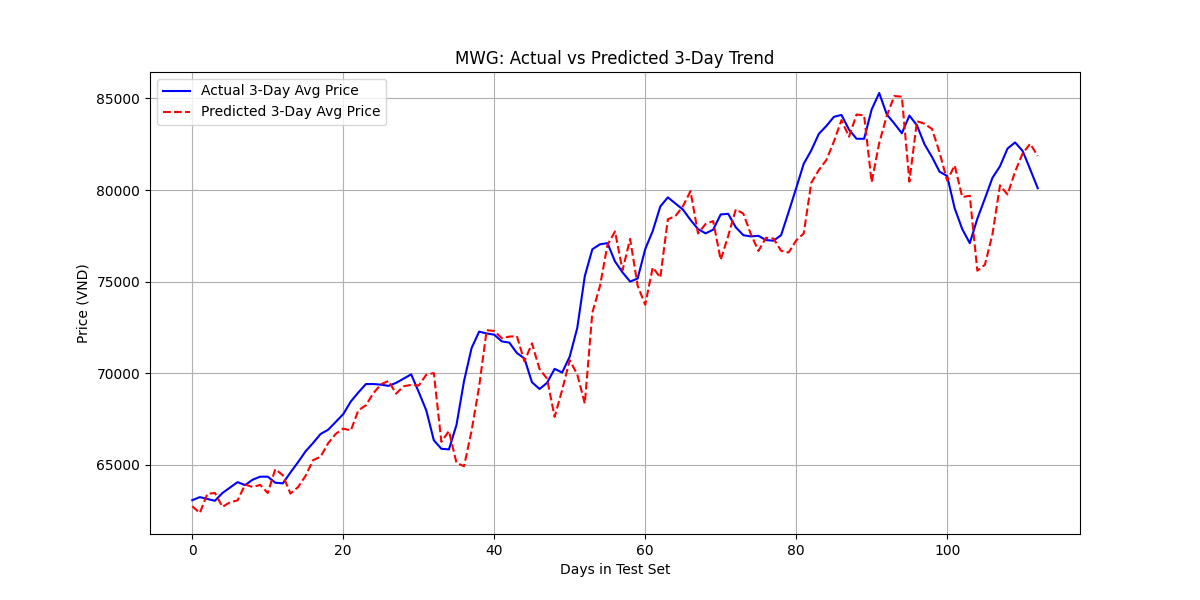

--------------------------------------------------------------------------------


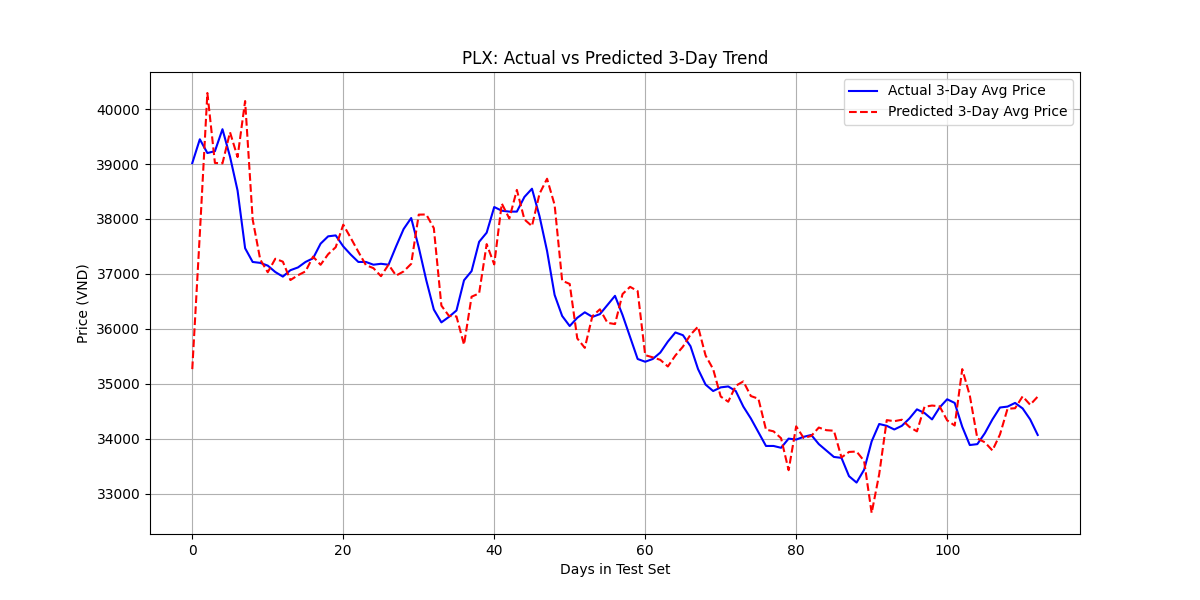

--------------------------------------------------------------------------------


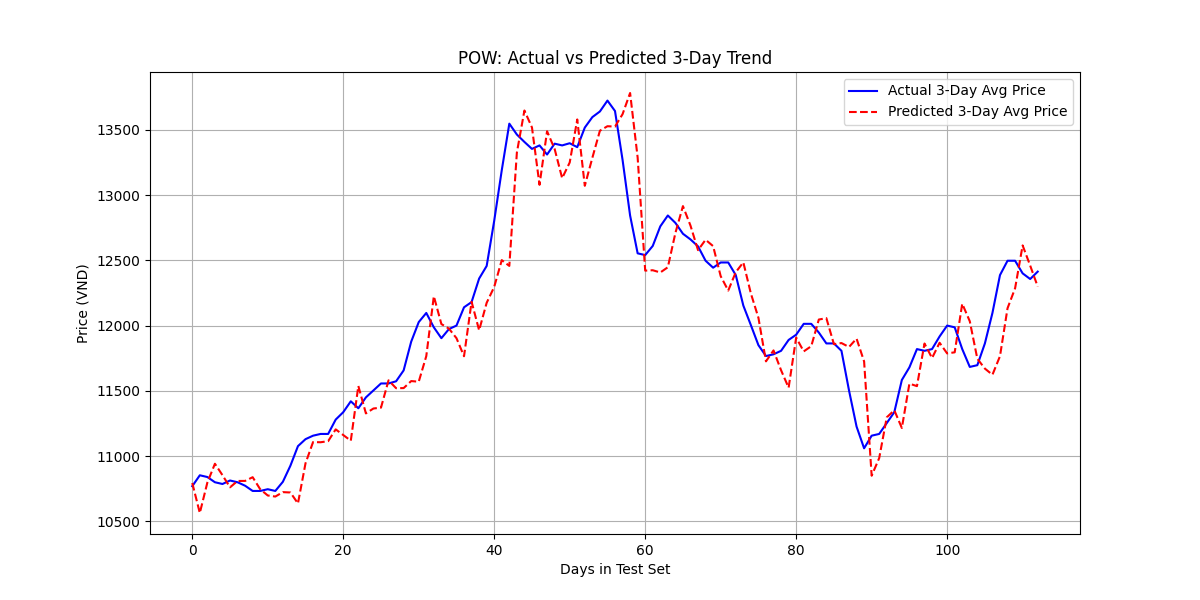

--------------------------------------------------------------------------------


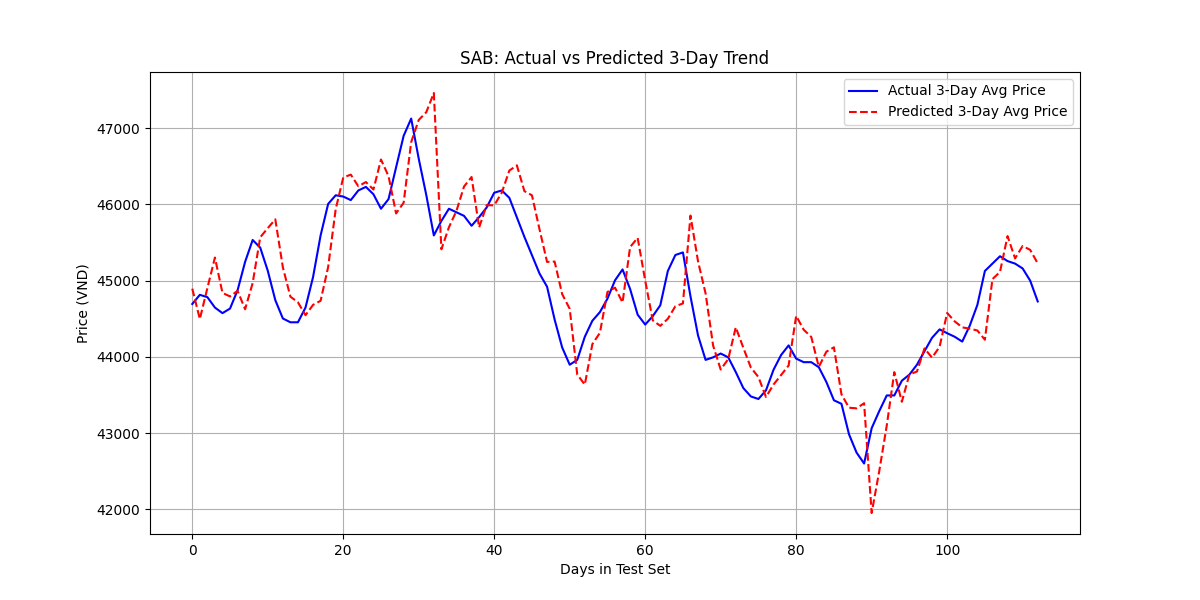

--------------------------------------------------------------------------------


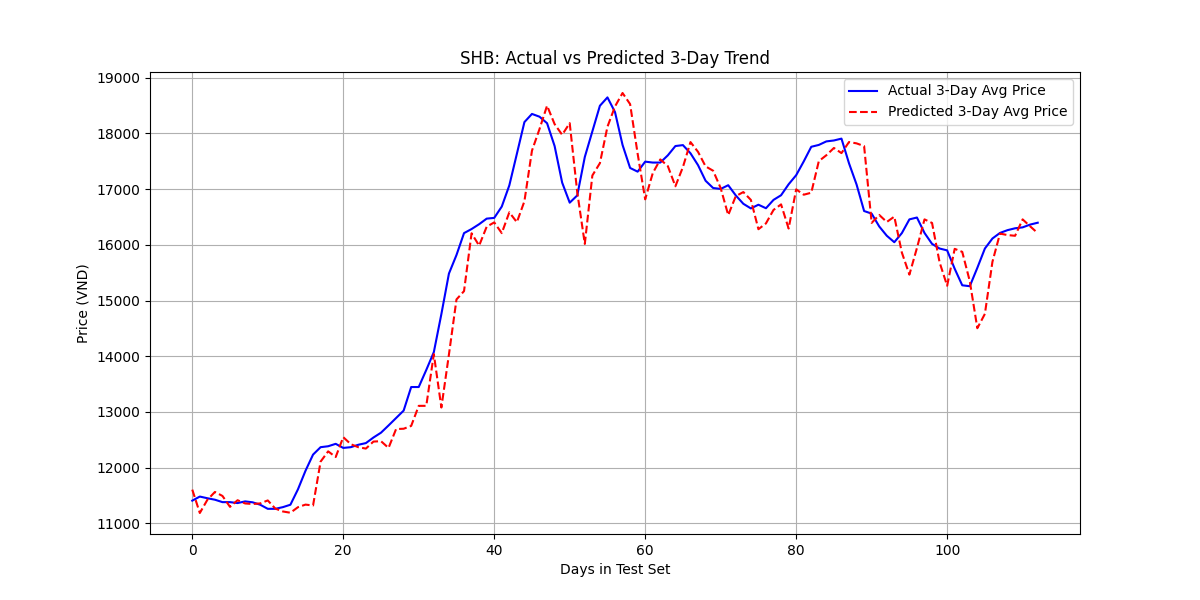

--------------------------------------------------------------------------------


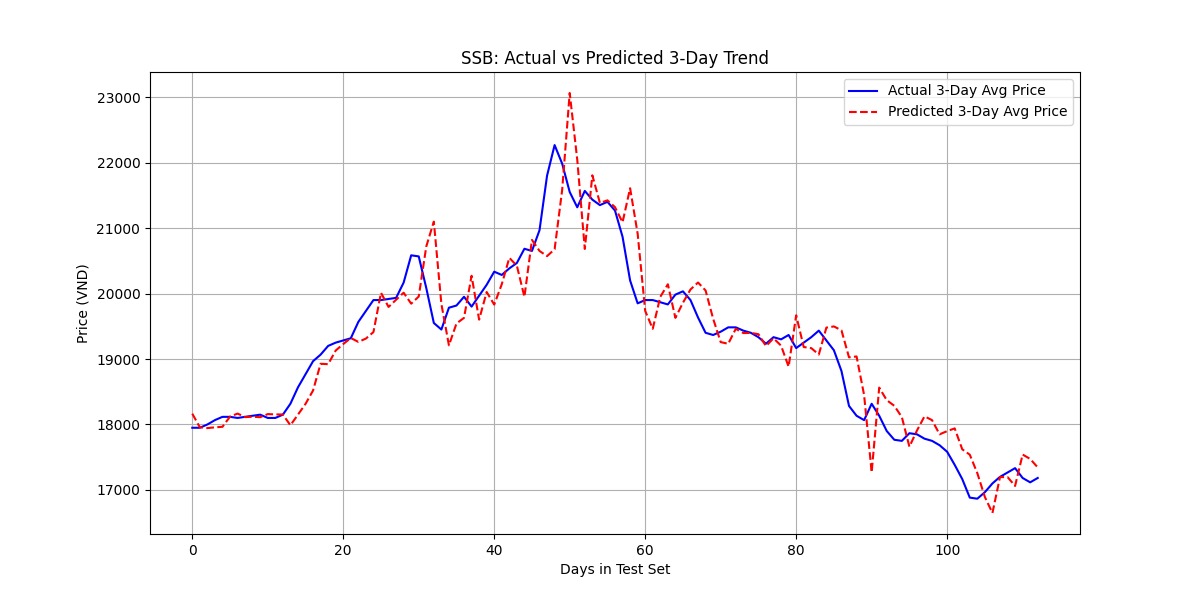

--------------------------------------------------------------------------------


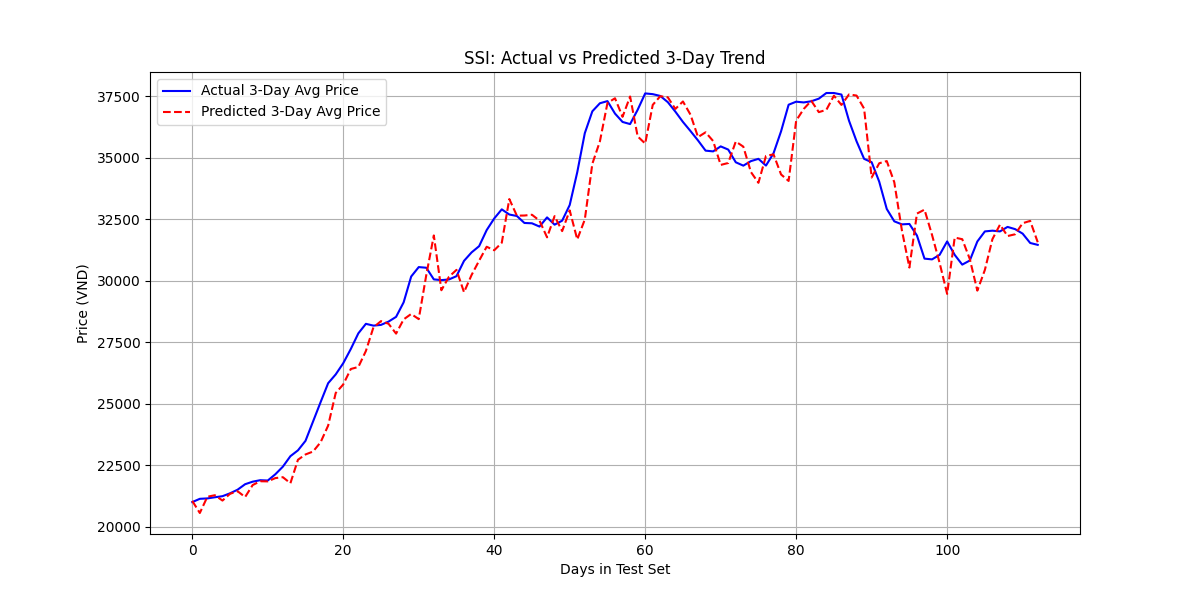

--------------------------------------------------------------------------------


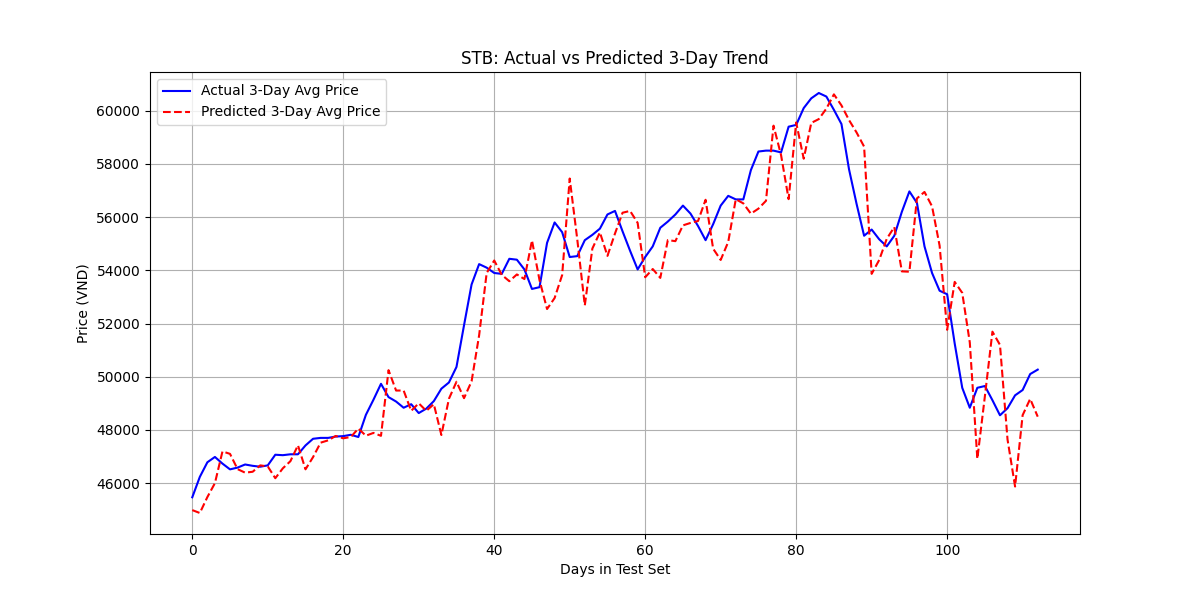

--------------------------------------------------------------------------------


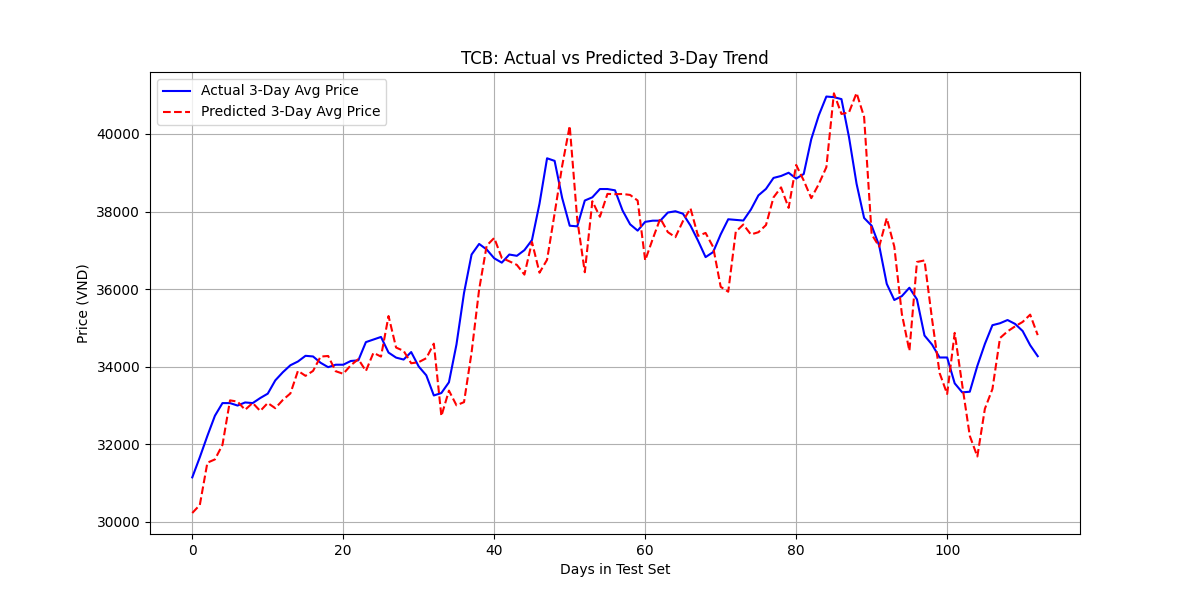

--------------------------------------------------------------------------------


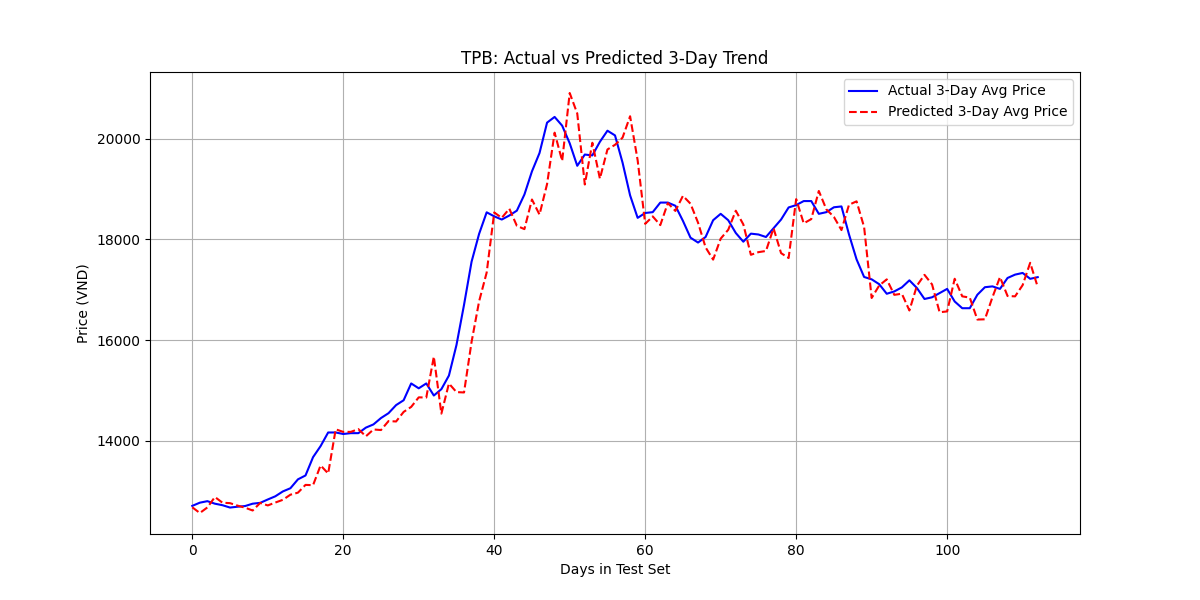

--------------------------------------------------------------------------------


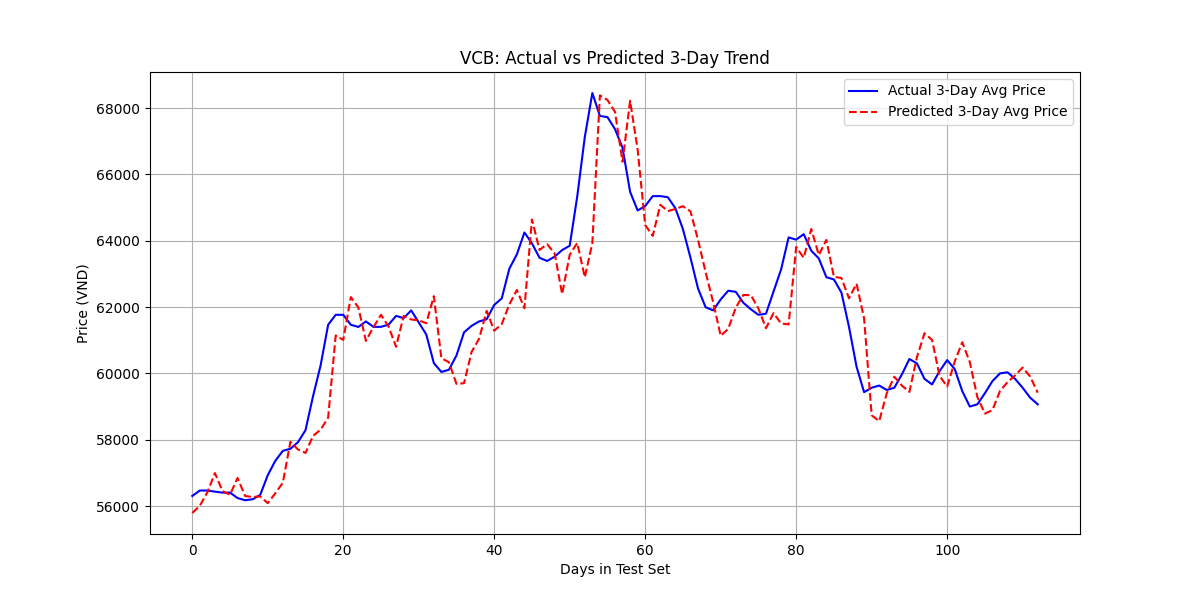

--------------------------------------------------------------------------------


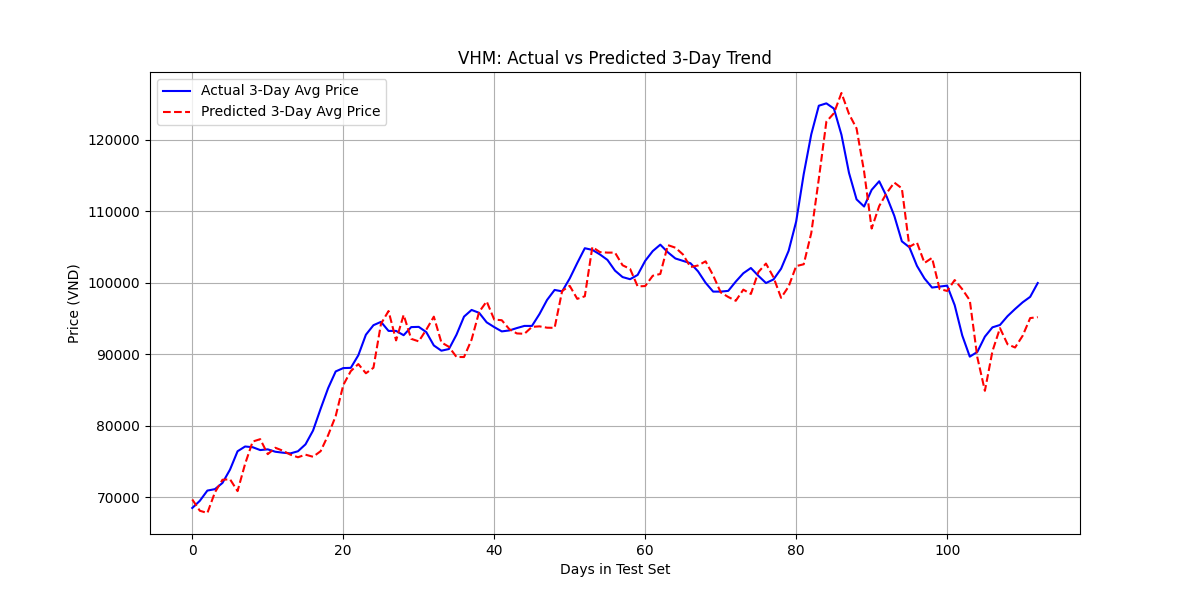

--------------------------------------------------------------------------------


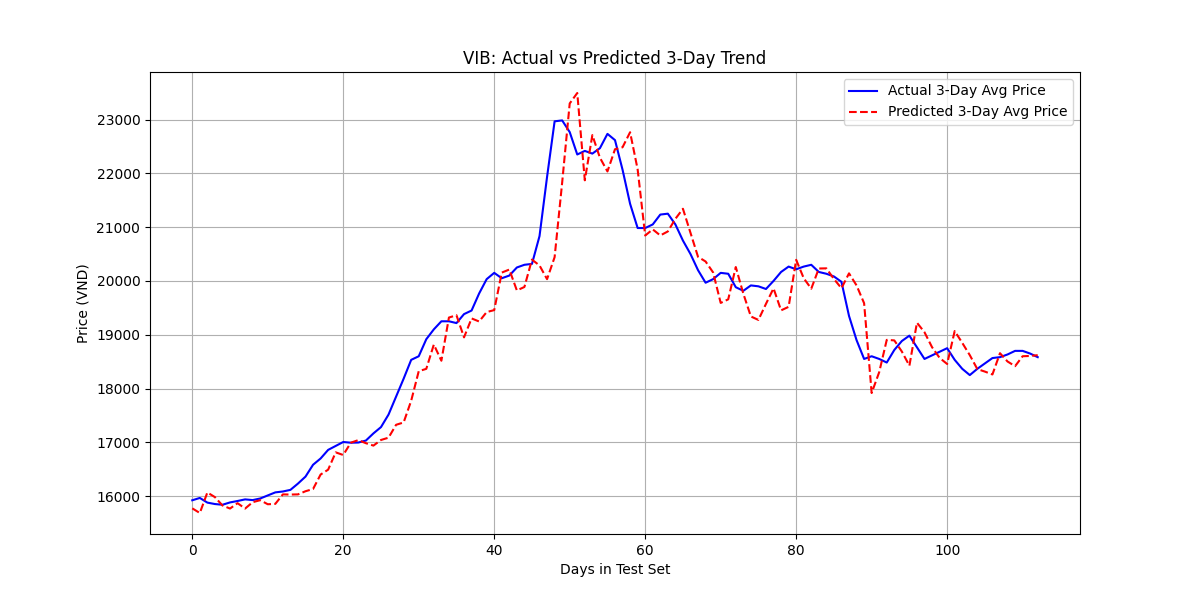

--------------------------------------------------------------------------------


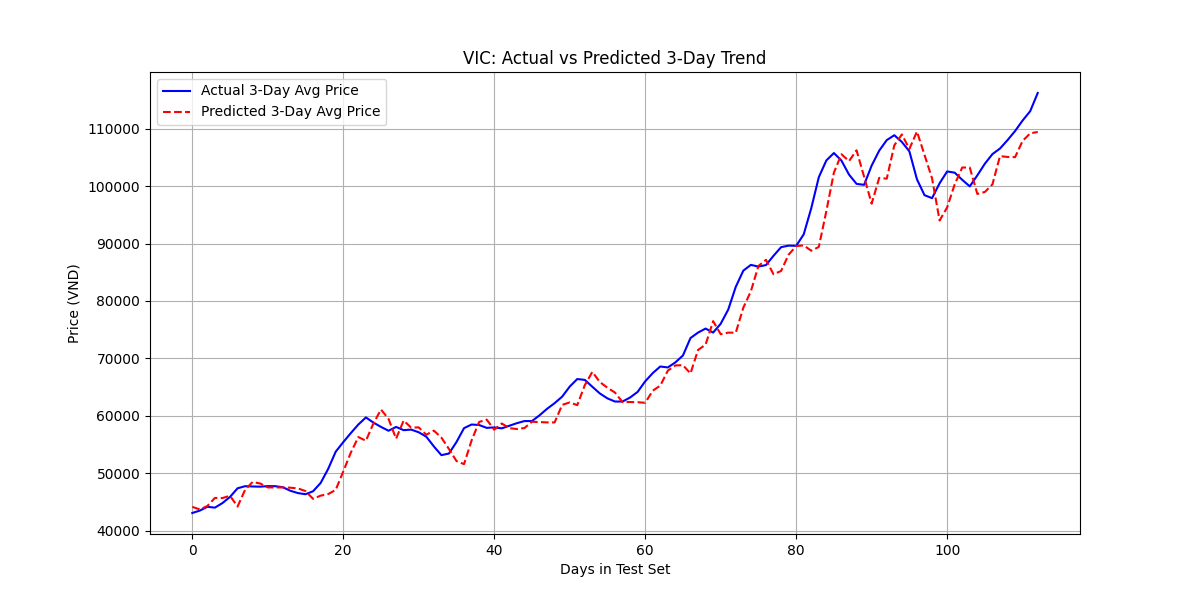

--------------------------------------------------------------------------------


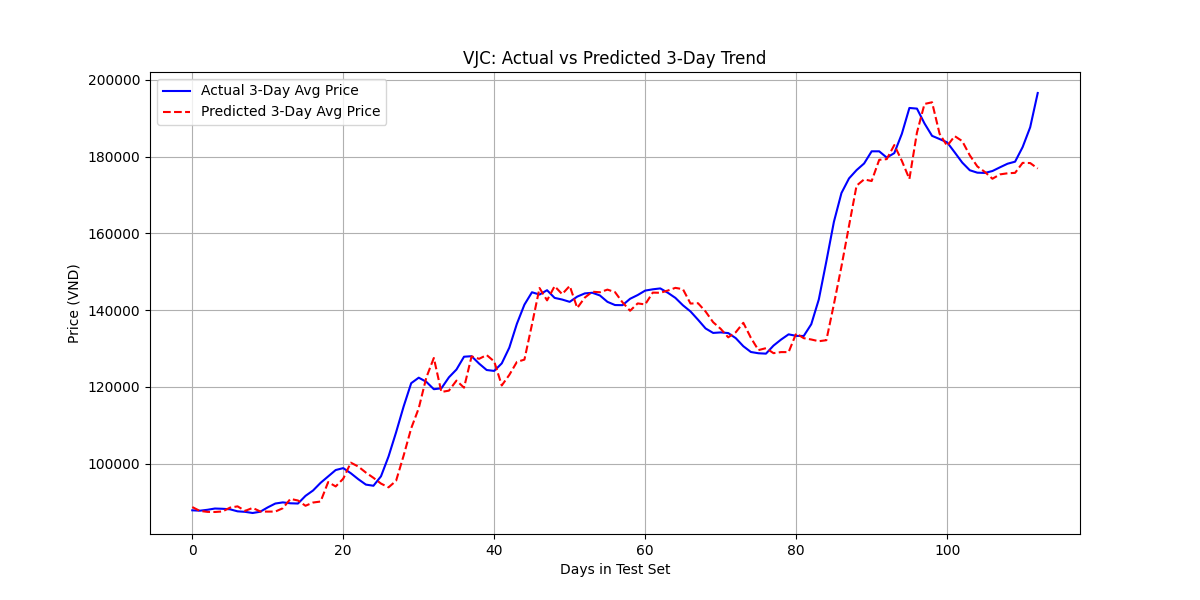

--------------------------------------------------------------------------------


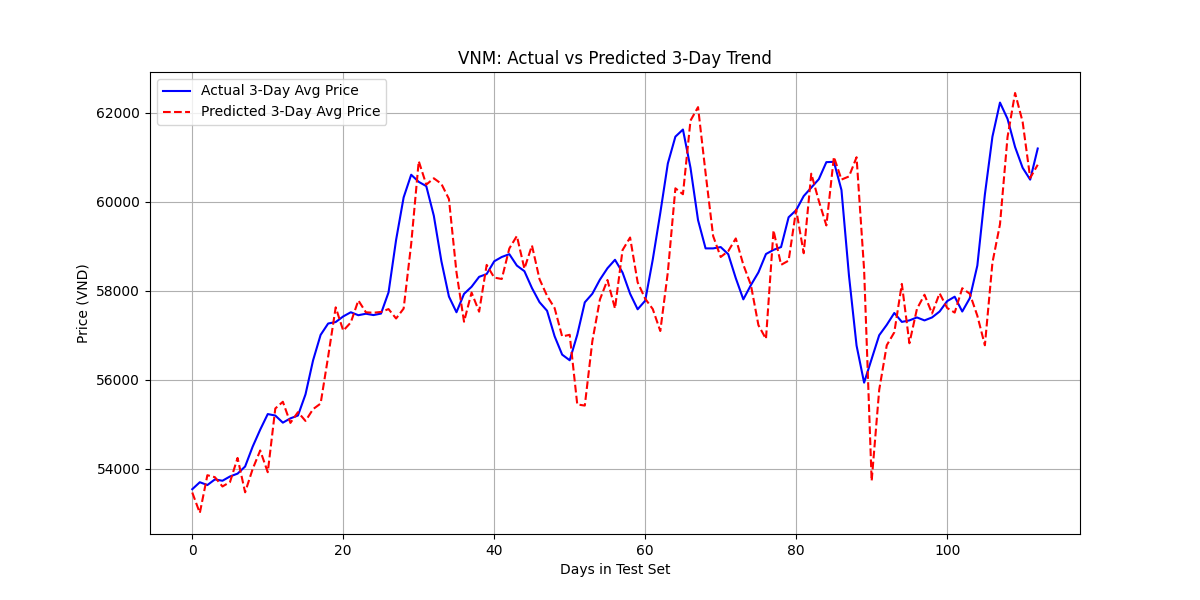

--------------------------------------------------------------------------------


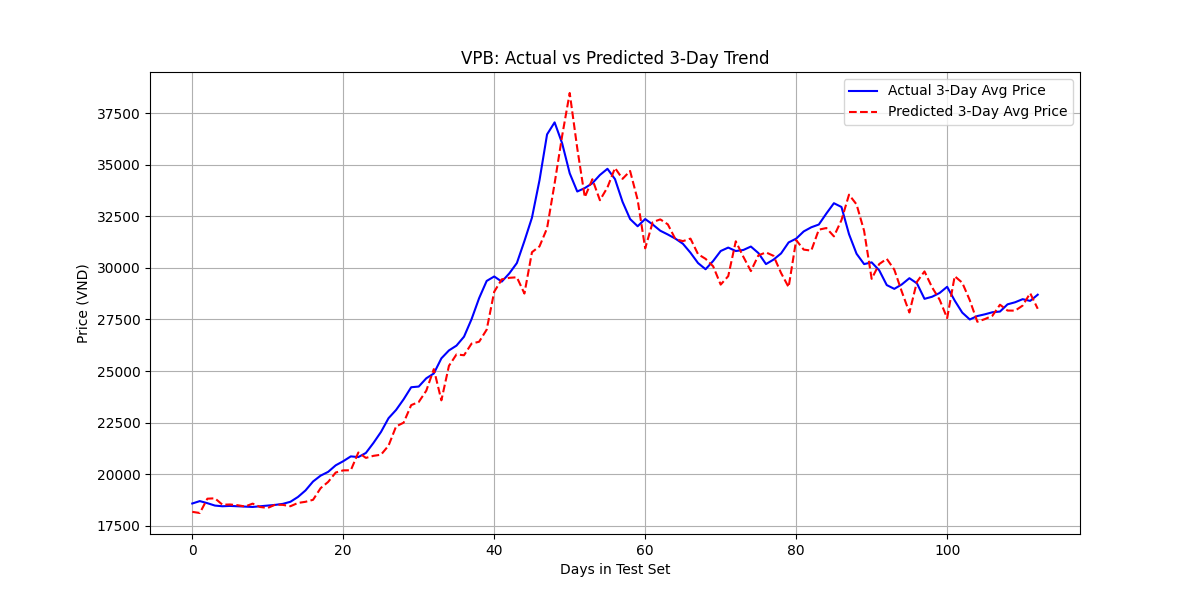

--------------------------------------------------------------------------------


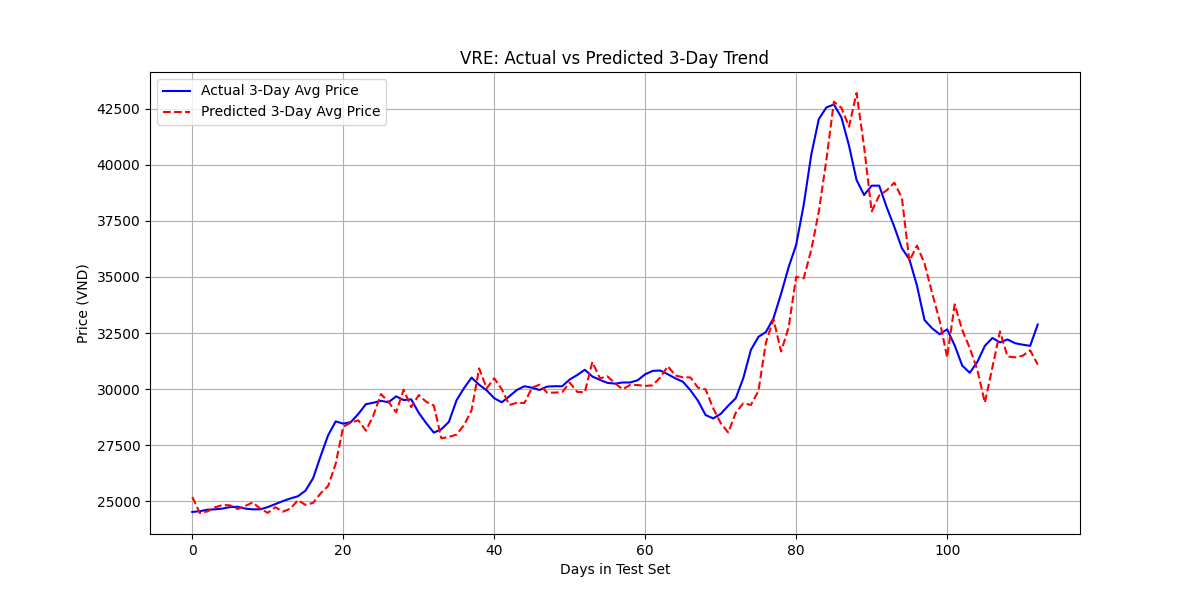

--------------------------------------------------------------------------------


In [11]:
import os
from IPython.display import Image, display

# The folder where your plots are saved
plot_dir = "/kaggle/working/VN30_Trend_Plots"

# Get a list of all PNG files in the folder and sort them alphabetically
image_files = sorted([f for f in os.listdir(plot_dir) if f.endswith('.png')])

print(f"Found {len(image_files)} plots. Displaying them now...\n")

# Loop through and display each image
for img_name in image_files:
    img_path = os.path.join(plot_dir, img_name)
    display(Image(filename=img_path))
    print("-" * 80) # Just a visual separator line